# Sudan Climate Data Analysis (2015–2026)

## Objective
This notebook analyzes climate data to identify trends and patterns.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

The dataset is loaded from a local CSV file. A new column is added to indicate the country for easier identification during analysis.

In [2]:
df = pd.read_csv("../data/sudan.csv")
df["Country"] = "Sudan"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


## Date Conversion

The dataset provides YEAR and DOY (Day of Year). These are combined to create a proper datetime column, which is necessary for time series analysis. A Month column is also extracted for seasonal analysis.

In [3]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df[["YEAR", "DOY", "Date", "Month"]].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


## Handling Missing Values

The dataset may contain -999 values, which represent missing or invalid data from the source. These are replaced with NaN to avoid distortion in statistical analysis.

In [4]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27,3
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3


## Duplicate Records

We check for duplicate rows in the dataset to ensure data integrity.

In [5]:
duplicates = df.duplicated().sum()
duplicates

df.drop_duplicates(inplace=True)


duplicate rows were detected and removed.

## Summary Statistics

Basic descriptive statistics are computed to understand the distribution of climate variables such as temperature, precipitation, and humidity.

In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


### Interpretation

- The mean temperature (T2M) indicates generally mild to warm conditions.
- The maximum temperature (T2M_MAX) shows occasional high-temperature extremes, which may indicate heat stress periods.
- Precipitation (PRECTOTCORR) appears highly variable, suggesting seasonal rainfall patterns.
- Relative humidity (RH2M) values suggest moderate atmospheric moisture levels.

## Missing Value Analysis

We evaluate the number and percentage of missing values in each column to assess data quality.

In [7]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent
})

,Missing Values,Percentage (%)
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Columns with more than 5% missing values may require careful handling, such as imputation or exclusion, depending on their importance to the analysis. We have no missing values here.

## Outlier Detection

Z-scores are used to identify extreme values in selected climate variables. Observations with absolute Z-score greater than 3 are considered potential outliers.

In [8]:
import scipy
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
outliers

T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64

### Outlier Analysis Interpretation

Outlier analysis shows that precipitation contains the highest number of extreme values, indicating occasional intense rainfall events.

Other variables exhibit relatively few outliers, suggesting more stable patterns.

These outliers are retained as they likely represent genuine climatic extremes.

## Handling Missing Values

Missing values are handled using forward-fill for continuous weather variables. Rows with excessive missing data may be dropped to maintain data quality.

In [9]:
##df.fillna(method='ffill', inplace=True)
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27,3
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3


Forward-fill is applied to preserve temporal continuity in the dataset. This approach assumes that short gaps in measurements can be approximated using previous observations.

Rows with excessive missing values are removed to avoid unreliable analysis.

In [10]:
df.to_csv("../data/sudan_clean.csv", index=False)

The cleaned dataset is saved for further analysis and cross-country comparison.

## Temperature Trend Analysis

We analyze monthly average temperature (T2M) over time to identify long-term trends and seasonal patterns.

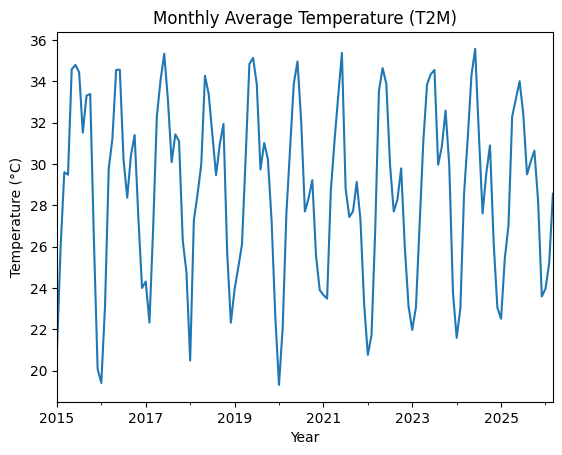

In [11]:
# Create a time-indexed DataFrame
df_time = df.set_index("Date")

# Monthly average temperature
monthly_temp = df_time["T2M"].resample("ME").mean()

# Plot
plt.figure()
monthly_temp.plot()
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

### Temperature Trend Interpretation

The temperature trend shows strong and consistent seasonal cycles, with significant variation between cooler and hotter months.

Temperatures reach much higher levels compared to other countries, often exceeding 30°C, indicating a generally hot climate.

Despite seasonal fluctuations, the pattern remains stable over time, suggesting no significant long-term trend.

## Seasonal Temperature Pattern

To better understand seasonal behavior, we examine the average temperature for each month across all years.

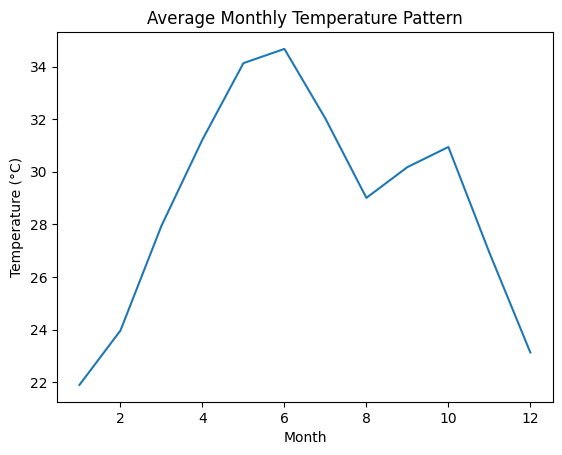

In [12]:
monthly_temp_pattern = df.groupby("Month")["T2M"].mean()

plt.figure()
monthly_temp_pattern.plot()
plt.title("Average Monthly Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Seasonal Temperature Pattern Interpretation

The seasonal temperature pattern shows a clear unimodal distribution, with temperatures peaking منتصف the year and dropping during the early and late months.

This indicates a hot season during mid-year, followed by relatively cooler periods.

Such a pattern is characteristic of arid and semi-arid climates with strong solar influence.

## Precipitation Analysis

We examine monthly total precipitation to identify rainfall patterns and seasonal peaks.

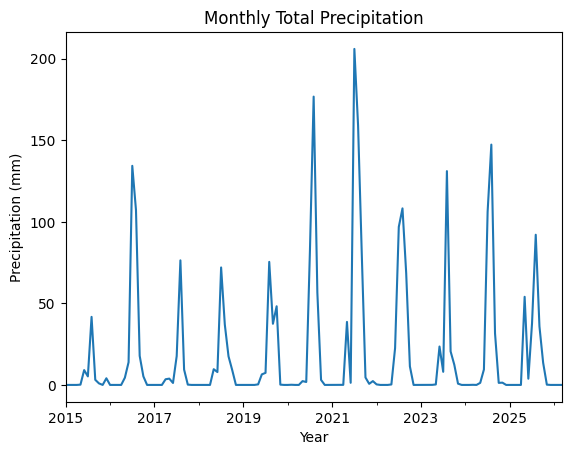

In [13]:
monthly_rain = df_time["PRECTOTCORR"].resample("ME").sum()

plt.figure()
monthly_rain.plot()
plt.title("Monthly Total Precipitation")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm)")
plt.show()

### Precipitation Trend Interpretation

The rainfall trend shows extremely low precipitation for most of the year, interrupted by occasional sharp spikes.

This indicates that rainfall is rare and occurs in short, intense bursts rather than being evenly distributed.

Such patterns are typical of dry climates with limited and unpredictable rainfall.

## Seasonal Precipitation Pattern

We examine the average precipitation for each month to better understand the timing and concentration of rainy seasons.

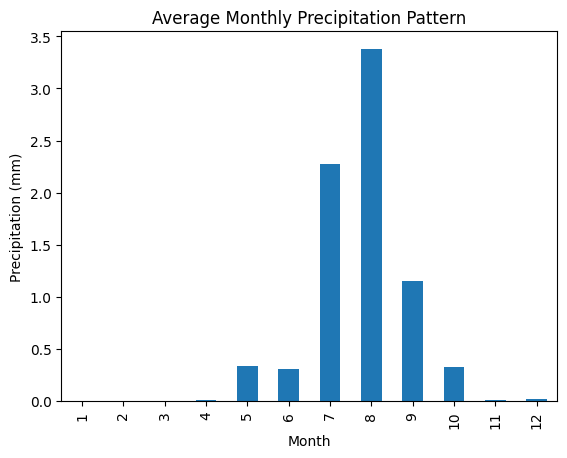

In [14]:
monthly_rain_pattern = df.groupby("Month")["PRECTOTCORR"].mean()

plt.figure()
monthly_rain_pattern.plot(kind="bar")
plt.title("Average Monthly Precipitation Pattern")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.show()

### Seasonal Precipitation Pattern Interpretation

The precipitation pattern shows a single, short rainy season concentrated around mid-year, particularly between July and September.

Outside of this period, rainfall is minimal or absent.

This unimodal rainfall pattern indicates strong seasonality and reliance on a brief wet season.

## Correlation Analysis

We examine relationships between key climate variables using a correlation matrix. This helps identify how different environmental factors interact with each other.

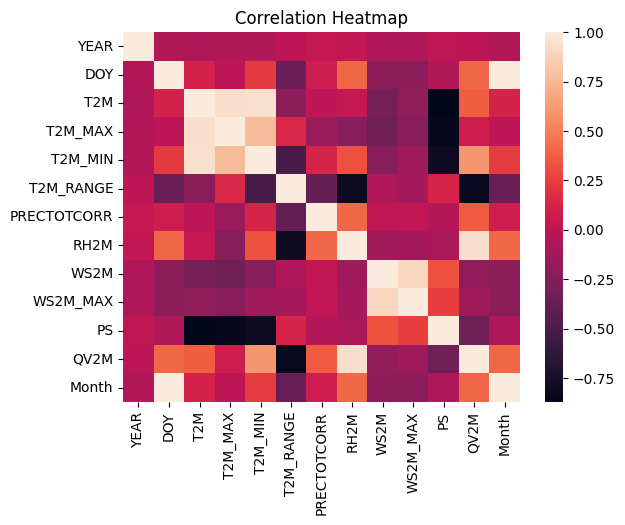

In [15]:
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap Interpretation

The heatmap shows strong positive correlations among temperature variables, indicating consistent temperature measurements.

A negative relationship is observed between temperature and humidity, reflecting drier conditions at higher temperatures.

Precipitation is positively associated with humidity, confirming the importance of moisture in rainfall occurrence.

Other variables, such as wind speed, show relatively weak correlations.

## Variable Relationships

Scatter plots are used to further explore relationships between key variables identified in the correlation analysis.

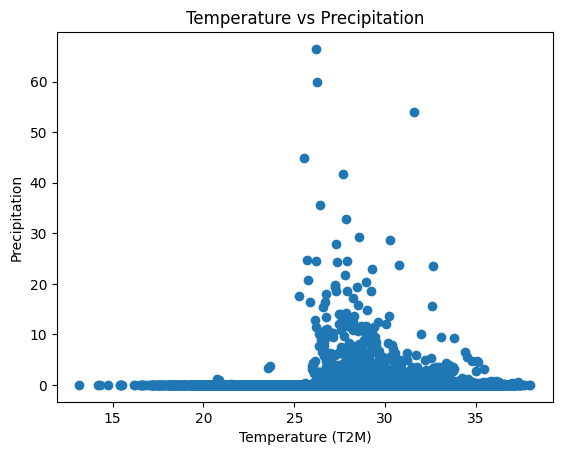

In [16]:
plt.figure()
plt.scatter(df["T2M"], df["PRECTOTCORR"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Precipitation")
plt.title("Temperature vs Precipitation")
plt.show()

### Temperature vs Precipitation Interpretation

The relationship between temperature and precipitation is weak and non-linear.

Rainfall tends to occur within a moderate temperature range, while very high temperatures are associated with little to no precipitation.

This suggests that temperature alone is not a strong determinant of rainfall.

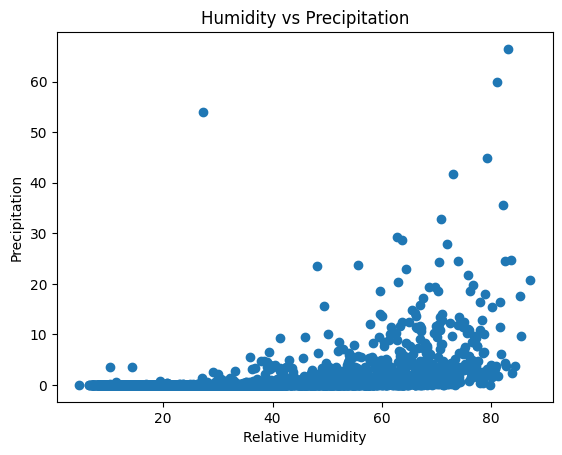

In [17]:
plt.figure()
plt.scatter(df["RH2M"], df["PRECTOTCORR"])
plt.xlabel("Relative Humidity")
plt.ylabel("Precipitation")
plt.title("Humidity vs Precipitation")
plt.show()

### Humidity vs Precipitation Interpretation

The scatter plot shows a positive relationship between humidity and precipitation.

Rainfall occurs almost exclusively at higher humidity levels, while low humidity conditions correspond to dry periods.

This highlights the critical role of atmospheric moisture in triggering rainfall events.

## Precipitation Distribution Analysis

To better understand the distribution of precipitation, a histogram is plotted. Since precipitation data is typically highly skewed, a logarithmic transformation is applied to improve visualization and highlight underlying patterns.

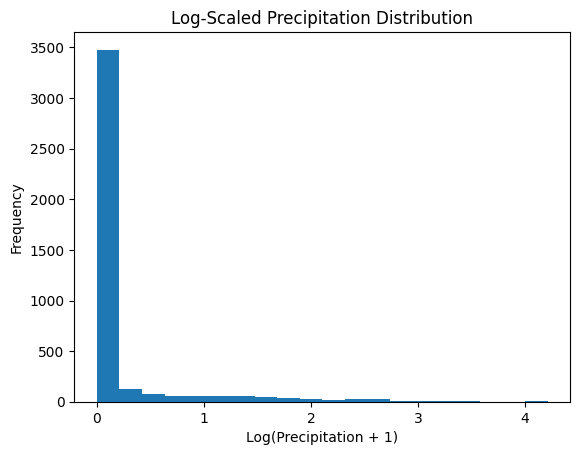

In [18]:
import numpy as np

plt.figure()
plt.hist(np.log1p(df["PRECTOTCORR"]), bins=20)
plt.title("Log-Scaled Precipitation Distribution")
plt.xlabel("Log(Precipitation + 1)")
plt.ylabel("Frequency")
plt.show()

### Precipitation Distribution Interpretation

The precipitation distribution is highly right-skewed, with most values clustered near zero and a few extreme high values.

Applying a logarithmic transformation improves visualization and confirms the presence of rare but intense rainfall events.

This reflects the irregular and sparse nature of precipitation in the region.

## Multivariable Relationship Analysis

A bubble chart is used to examine the relationship between temperature (T2M) and relative humidity (RH2M), with precipitation represented by the size of the bubbles.

This visualization helps capture how multiple climate variables interact simultaneously, providing deeper insight into the conditions associated with rainfall events.

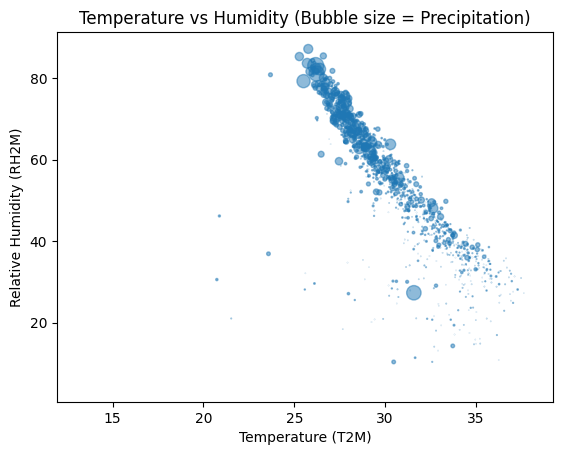

In [19]:
plt.figure()
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2,  # scale bubbles
    alpha=0.5
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("Temperature vs Humidity (Bubble size = Precipitation)")
plt.show()

### Bubble Chart Interpretation

The bubble chart reveals a negative relationship between temperature and humidity, where higher temperatures are associated with lower humidity levels.

Larger bubbles, representing higher precipitation, are concentrated in areas with higher humidity and moderate temperatures.

This indicates that rainfall is most likely when sufficient moisture is present, regardless of high temperature conditions.

## Key Insights

- Sudan exhibits a hot and arid climate, with consistently high temperatures throughout the year.
- Temperature follows a clear seasonal pattern, peaking منتصف the year.
- Rainfall is extremely limited and occurs only خلال a short rainy season between July and September.
- Precipitation is highly irregular, with rare but intense rainfall events.
- Humidity plays a critical role in rainfall, while temperature shows limited direct influence.
- The climate shows strong dryness for most of the year, indicating vulnerability to drought conditions.

These findings highlight Sudan’s predominantly dry climate and strong seasonal dependence on a short wet period.